# Evaluation Against New Annotations
Apply conversion rules to model predictions, then evaluate against the **new version** ground truth.

Flow: model predicted labels → apply rules → compare vs `sampleN_new_dmp.json`

In [1]:
import json
from pathlib import Path
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dmpbridge.evaluation.evaluate import (
    tokenize, containment, NEW_MANUAL_DIR, LLM_DIR
)

LABELS  = ['title', 'section.title', 'section.description', 'question.text', 'answer.text']
SHORT   = ['title', 'sec.title', 'sec.desc', 'q.text', 'ans.text']
COLORS  = ['#1e3a5f', '#2563eb', '#60a5fa', '#f59e0b', '#10b981']
MODELS  = [
    ('llama3.1:8b',  'llama3.1-8b_pdfplumber_whole_doc',  '#1d4ed8'),
    ('llama3.3:70b', 'llama3.3-70b_pdfplumber_whole_doc', '#7c3aed'),
    ('gemma4:e4b',   'gemma4-e4b_pdfplumber_whole_doc',   '#059669'),
]
EXCLUDE = [1, 2]
GENERIC_TITLES = {'data management plan', 'data management',
                  'resource/data sharing plan', 'resource / data sharing plan'}
print('Config ready.')

Config ready.


## Step 1 — New Version Ground Truth Extractor

In [2]:
def extract_gold_new(path):
    """Extract (text, label) from new-version JSON. question.text always shown."""
    data     = json.loads(path.read_text(encoding='utf-8'))
    template = data.get('narrative', data).get('template', {})
    pairs    = []
    title = template.get('title', '').strip()
    if title:
        pairs.append((title, 'title'))
    for section in template.get('section', []):
        sec_title = section.get('title', '').strip()
        q_texts   = [q.get('text', '').strip() for q in section.get('question', [])]
        if sec_title and sec_title not in q_texts:
            pairs.append((sec_title, 'section.title'))
        if section.get('description'):
            pairs.append((section['description'].strip(), 'section.description'))
        for q in section.get('question', []):
            qt = q.get('text', '').strip()
            if qt:
                pairs.append((qt, 'question.text'))
            ans = q.get('answer', {})
            at  = (ans.get('json', {}).get('answer', '') or ans.get('text', '')) if isinstance(ans, dict) else ''
            if at:
                pairs.append((at.strip(), 'answer.text'))
    return pairs

# quick check
ex = extract_gold_new(NEW_MANUAL_DIR / 'sample5_new_dmp.json')
print(f'sample5 new GT: {len(ex)} items')
for t, l in ex[:6]:
    print(f'  {l:<25} {t[:55]}')

sample5 new GT: 13 items
  section.title             DATA MANAGEMENT PLAN
  question.text             REVIEW OF PROPOSAL COMPONENTS
  answer.text               The proposal is separated into three sections. • Sectio
  question.text             TYPES OF DATA
  answer.text               The PI and PhD student will be responsible for all data
  question.text             DATA AND METADATA STANDARDS


## Step 2 — Apply Rules to Predicted Labels

In [3]:
def apply_rules(blocks, new_gt_path):
    """
    Rule 1 only: if the model predicted section.title but that text appears
    as question.text in the new ground truth → relabel as question.text.
    """
    new_gt      = extract_gold_new(new_gt_path)
    new_q_texts = {t for t, l in new_gt if l == 'question.text'}

    result = []
    for b in blocks:
        text = (b.get('text') or '').strip()
        lbl  = b.get('label', '')
        if lbl == 'section.title' and text in new_q_texts:
            lbl = 'question.text'
        result.append((text, lbl))
    return result

# quick check on sample5 llama3.1:8b
blocks5 = json.loads((LLM_DIR / 'llama3.1-8b_pdfplumber_whole_doc/sample5.json').read_text(encoding='utf-8'))
conv5   = apply_rules(blocks5, NEW_MANUAL_DIR / 'sample5_new_dmp.json')
changed = [(t, b['label'], l) for (t, l), b in zip(conv5, blocks5) if b['label'] != l]
print(f'sample5: {len(changed)} label(s) changed by Rule 1')
for t, old, new in changed:
    print(f'  {old:<20} → {new:<20} | {t[:55]}')

sample5: 6 label(s) changed by Rule 1
  section.title        → question.text        | REVIEW OF PROPOSAL COMPONENTS
  section.title        → question.text        | TYPES OF DATA
  section.title        → question.text        | DATA AND METADATA STANDARDS
  section.title        → question.text        | POLICIES FOR ACCESS AND SHARING
  section.title        → question.text        | POLICIES AND PROVISIONS FOR RE-USE, RE-DISTRIBUTION
  section.title        → question.text        | PLANS FOR ARCHIVING AND PRESERVATION OF ACCESS


## Step 3 — Evaluate All Models vs New Ground Truth

In [4]:
def evaluate_pairs(predicted, gold):
    """
    For each gold item, find the best-matching predicted block.
    Match score = containment(predicted_tokens, gold_tokens):
      fraction of predicted block's tokens that appear in the gold text.
    Same direction as the original evaluate.py.
    """
    conf = defaultdict(int)
    used = set()
    for g_text, g_lbl in gold:
        g_tok = tokenize(g_text)
        best_s, best_j, best_pl = 0.0, None, None
        for j, (p_text, p_lbl) in enumerate(predicted):
            if j in used: continue
            s = containment(tokenize(p_text), g_tok)   # fraction of predicted tokens in gold
            if s > best_s:
                best_s, best_j, best_pl = s, j, p_lbl
        if best_j is not None and best_s >= 0.75:
            used.add(best_j)
            conf[(g_lbl, best_pl)] += 1
        else:
            conf[(g_lbl, '__no_match__')] += 1
    return conf


all_results = {}

for name, tag, color in MODELS:
    tag_dir = LLM_DIR / tag
    if not tag_dir.exists():
        print(f'{name}: no output directory, skipping')
        continue

    conf_total = defaultdict(int)
    per_sample = []

    for i in range(1, 11):
        if i in EXCLUDE: continue
        pred_path = tag_dir / f'sample{i}.json'
        gt_path   = NEW_MANUAL_DIR / f'sample{i}_new_dmp.json'
        if not pred_path.exists() or not gt_path.exists(): continue

        blocks    = json.loads(pred_path.read_text(encoding='utf-8'))
        predicted = apply_rules(blocks, gt_path)
        gold      = extract_gold_new(gt_path)
        conf      = evaluate_pairs(predicted, gold)

        total   = len(gold)
        correct = sum(v for (g, p), v in conf.items() if g == p)
        per_sample.append({'sample': f'sample{i}', 'total': total,
                           'correct': correct, 'accuracy': correct / total})
        for k, v in conf.items():
            conf_total[k] += v

    all_results[name] = {'conf': conf_total, 'per_sample': per_sample, 'color': color}
    print(f'{name}: done ({len(per_sample)} samples)')

llama3.1:8b: done (8 samples)
llama3.3:70b: done (8 samples)
gemma4:e4b: done (8 samples)


## F1 Score per Label — After Rule Conversion

Model                  title   sec.title    sec.desc      q.text    ans.text
----------------------------------------------------------------------------
llama3.1:8b            22.2%        0.0%        0.0%       63.9%       88.5%
llama3.3:70b           22.2%        0.0%       28.6%       68.7%       80.7%
gemma4:e4b              0.0%        0.0%       28.6%       66.7%       80.7%


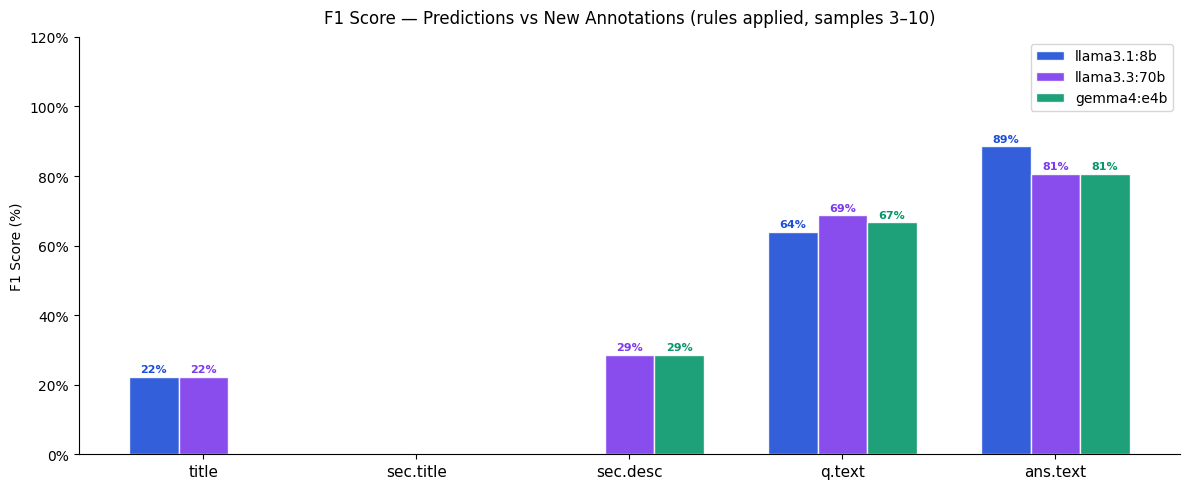

In [5]:
def compute_f1(conf, lbl):
    tp = conf.get((lbl, lbl), 0)
    fp = sum(v for (g, p), v in conf.items() if p == lbl and g != lbl)
    fn = sum(v for (g, p), v in conf.items() if g == lbl and p != lbl)
    fn += conf.get((lbl, '__no_match__'), 0)
    p  = tp / (tp + fp) if (tp + fp) else 0
    r  = tp / (tp + fn) if (tp + fn) else 0
    return 2 * p * r / (p + r) if (p + r) else 0

f1_data, colors_list = {}, []
for name, tag, color in MODELS:
    if name not in all_results: continue
    f1_data[name] = {lbl: compute_f1(all_results[name]['conf'], lbl) for lbl in LABELS}
    colors_list.append(color)

df_f1 = pd.DataFrame(f1_data).T * 100
print(f"{'Model':<16}" + ''.join(f'{s:>12}' for s in SHORT))
print('-' * 76)
for m, row in df_f1.iterrows():
    print(f'{m:<16}' + ''.join(f'{v:>11.1f}%' for v in row))

xi, w = range(len(LABELS)), 0.7 / len(f1_data)
fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, color) in enumerate(zip(df_f1.index, colors_list)):
    offset = (i - len(df_f1) / 2 + 0.5) * w
    bars = ax.bar([x + offset for x in xi], df_f1.loc[name], width=w,
                  label=name, color=color, edgecolor='white', alpha=0.9)
    for bar, v in zip(bars, df_f1.loc[name]):
        if v > 3:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                    f'{v:.0f}%', ha='center', va='bottom', fontsize=8,
                    fontweight='bold', color=color)
ax.set_xticks(list(xi))
ax.set_xticklabels(SHORT, fontsize=11)
ax.set_ylim(0, 120)
ax.set_ylabel('F1 Score (%)')
ax.set_title('F1 Score — Predictions vs New Annotations (rules applied, samples 3–10)', pad=10)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
sns.despine()
plt.tight_layout()
plt.show()

## Confusion Matrices — Predicted vs New Ground Truth

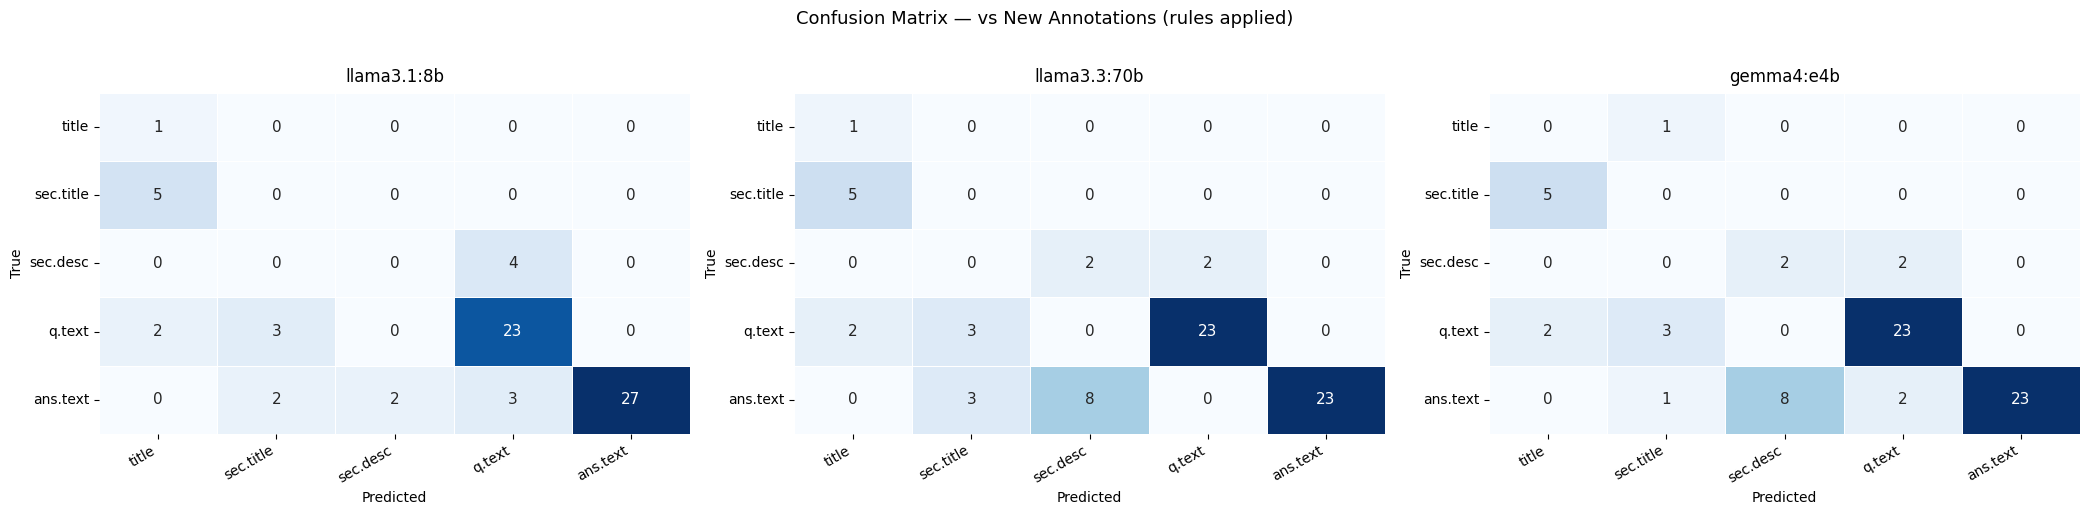

In [6]:
import numpy as np

def build_matrix(conf):
    mat = pd.DataFrame(0, index=LABELS, columns=LABELS)
    for (g, p), v in conf.items():
        if g in LABELS and p in LABELS:
            mat.loc[g, p] += v
    mat.index.name   = 'True'
    mat.columns.name = 'Predicted'
    return mat

n = len(all_results)
fig, axes = plt.subplots(1, n, figsize=(7 * n, 5))
if n == 1: axes = [axes]

for ax, (name, res) in zip(axes, all_results.items()):
    mat = build_matrix(res['conf'])
    sns.heatmap(mat, annot=True, fmt='d', cmap='Blues',
                linewidths=0.5, linecolor='white',
                ax=ax, cbar=False, annot_kws={'size': 11})
    ax.set_title(name, pad=8)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticklabels(SHORT, rotation=30, ha='right')
    ax.set_yticklabels(SHORT, rotation=0)

plt.suptitle('Confusion Matrix — vs New Annotations (rules applied)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## Save Converted Predictions as JSON

Saves rule-converted label files to `data/output/labeled_rule1_converted/{model_tag}/sampleN.json`.

In [7]:
OUT_ROOT = LLM_DIR.parent / 'labeled_rule1_converted'

for name, tag, color in MODELS:
    tag_dir = LLM_DIR / tag
    if not tag_dir.exists():
        continue

    out_dir = OUT_ROOT / tag
    out_dir.mkdir(parents=True, exist_ok=True)

    for i in range(1, 11):
        pred_path = tag_dir / f'sample{i}.json'
        gt_path   = NEW_MANUAL_DIR / f'sample{i}_new_dmp.json'
        if not pred_path.exists() or not gt_path.exists():
            continue

        blocks    = json.loads(pred_path.read_text(encoding='utf-8'))
        converted = apply_rules(blocks, gt_path)

        # Write back: copy original block, update only the label field
        out_blocks = []
        for block, (text, new_lbl) in zip(blocks, converted):
            out_block = dict(block)
            out_block['label_original'] = block['label']   # keep original for reference
            out_block['label'] = new_lbl
            out_blocks.append(out_block)

        out_path = out_dir / f'sample{i}.json'
        out_path.write_text(json.dumps(out_blocks, indent=2, ensure_ascii=False), encoding='utf-8')

    saved = list((OUT_ROOT / tag).glob('sample*.json'))
    print(f'{name}: saved {len(saved)} files → {OUT_ROOT / tag}')

print(f'\nAll files saved under: {OUT_ROOT}')

llama3.1:8b: saved 10 files → C:\Users\Nahid\dmpbridge\data\output\labeled_rule1_converted\llama3.1-8b_pdfplumber_whole_doc
llama3.3:70b: saved 10 files → C:\Users\Nahid\dmpbridge\data\output\labeled_rule1_converted\llama3.3-70b_pdfplumber_whole_doc
gemma4:e4b: saved 10 files → C:\Users\Nahid\dmpbridge\data\output\labeled_rule1_converted\gemma4-e4b_pdfplumber_whole_doc

All files saved under: C:\Users\Nahid\dmpbridge\data\output\labeled_rule1_converted
